# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Get Data From Github

In [2]:
patron_file = 'Patron.xlsx'
patron_visit_file = 'PatronInVisit.xlsx'
household_file = 'Household.xlsx'
household_visit_file = 'HouseHoldVisit.xlsx'

df_patron = pd.read_excel(patron_file)
df_patron_visit = pd.read_excel(patron_visit_file)
df_household = pd.read_excel(household_file)
df_household_visit = pd.read_excel(household_visit_file)

### Data Exploration

In [3]:
df_patron_visit.head(1)

,PK_PatronInVisit,FK_Patron,FK_HouseholdVisit,createdDateTime,createdBy
0,1,1,1,2019-05-09 08:24:41,Amanda Admin


In [4]:
df_patron.head(1)

,Unnamed: 0.1,Unnamed: 0,PK_Patron,FK_Household,AlternateID,Gender,Race,Ethnicity,PreferredLanguage,Military,...,PQ2,PQ3,VerificationDateTime,dateOfBirth,active,primaryContact,createdDateTime,createdBy,updatedDateTime,updatedBy
0,0,0,1,1001,NaN,F,White,Not Hispanic,English,NaN,...,NaN,NaN,2020-08-09 00:00:00,1999-09-09,True,True,2019-05-09 08:23:15,Amanda Admin,2019-05-09 08:23:15,Amanda Admin


In [5]:
df_household.head(1)

,PK_Household,Q1,Q2,Q3,Q4,Q5,Q6,TEFAP,Notes,homeless,...,Shop35,Shop36,Shop37,Shop38,createdDateTime,createdBy,updatedDateTime,updatedBy,FlaggedNote,TEFAPONLY
0,1001,Yes,No,OptOut,NaN,NaN,NaN,True,08/28/23 (AA) Laundry Detergent.\n10/12/19 (AA...,False,...,0.0,0.0,0.0,0.0,2019-05-09 08:23:14,Amanda Anderson,2023-08-28 11:06:21,Amanda Admin,NaN,False


In [6]:
df_household_visit.head(1)

,PK_HouseholdVisit,FK_Household,VisitDateTime,Track1,Track2,createdDateTime,createdBy,Track3
0,1,1001,2019-05-09 08:24:41,NaN,NaN,2019-05-09 08:24:41,Amanda Admin,NaN


In [7]:
df_patron_visit['createdDateTime'].describe()

count                            37748
mean     2024-11-13 03:37:31.490304256
min                2019-05-09 08:24:41
25%                2024-06-05 10:07:50
50%                2024-11-20 10:24:41
75%                2025-05-14 18:31:44
max                2025-10-08 18:54:26
Name: createdDateTime, dtype: object

### We need to create a dataset on which to train our model
We can sum aggregate the df_patron visits by date in order to see how many people come to the pantry each date

In [8]:
# Create new field for just the date
df_patron_visit['dateOfVisit'] = df_patron_visit['createdDateTime'].dt.date

In [9]:
df_patron_visit.head(1)

,PK_PatronInVisit,FK_Patron,FK_HouseholdVisit,createdDateTime,createdBy,dateOfVisit
0,1,1,1,2019-05-09 08:24:41,Amanda Admin,2019-05-09


In [10]:
visits = df_patron_visit.groupby('dateOfVisit')['FK_HouseholdVisit'].agg('count')
visits = visits.to_frame()
visits = visits[visits['FK_HouseholdVisit'] > 10]
x = np.array(visits.index)
y = np.array(visits.values)

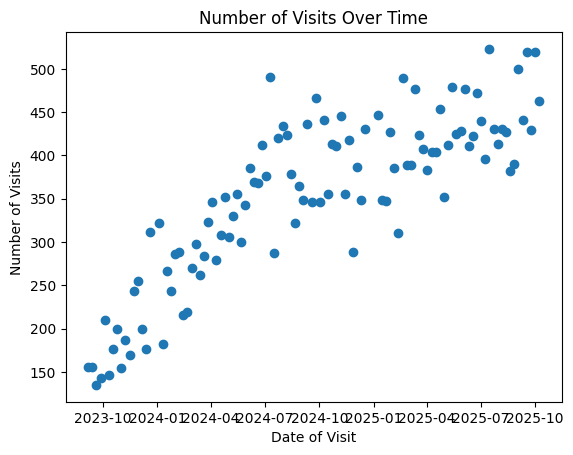

In [11]:
plt.scatter(x, y)
plt.xlabel('Date of Visit')
plt.ylabel('Number of Visits')
plt.title('Number of Visits Over Time')
plt.show()

### It seems that the number of patrons increases with time. We will need to account for this when training the model.

### Implementing Prophet for Forecasting

In [12]:
# Prepare data for Prophet
# Prophet requires columns to be named 'ds' (datestamp) and 'y' (numeric value)
from prophet import Prophet

prophet_df = pd.DataFrame({
    'ds': visits.index,
    'y': visits['FK_HouseholdVisit'].values
})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

prophet_df.head()

c:\Users\austi\CodeRepos\FoodPantry\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


,ds,y
0,2023-09-06,156
1,2023-09-13,156
2,2023-09-20,135
3,2023-09-27,143
4,2023-10-04,210


In [13]:
# Initialize and fit the Prophet model
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(prophet_df)

22:24:17 - cmdstanpy - INFO - Chain [1] start processing
22:24:17 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
# Create a dataframe for future predictions (e.g., predicting the next 365 days)
future = m.make_future_dataframe(periods=365)

# Predict the future values
forecast = m.predict(future)

# Show the last few predictions (yhat is the predicted value, with upper and lower confidence intervals)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
467,2026-10-04,497.224656,441.498416,549.777777
468,2026-10-05,497.636340,440.152646,551.529728
469,2026-10-06,498.018514,441.040866,554.147960
470,2026-10-07,520.943435,463.955613,575.235424
471,2026-10-08,498.574048,447.038588,550.129413


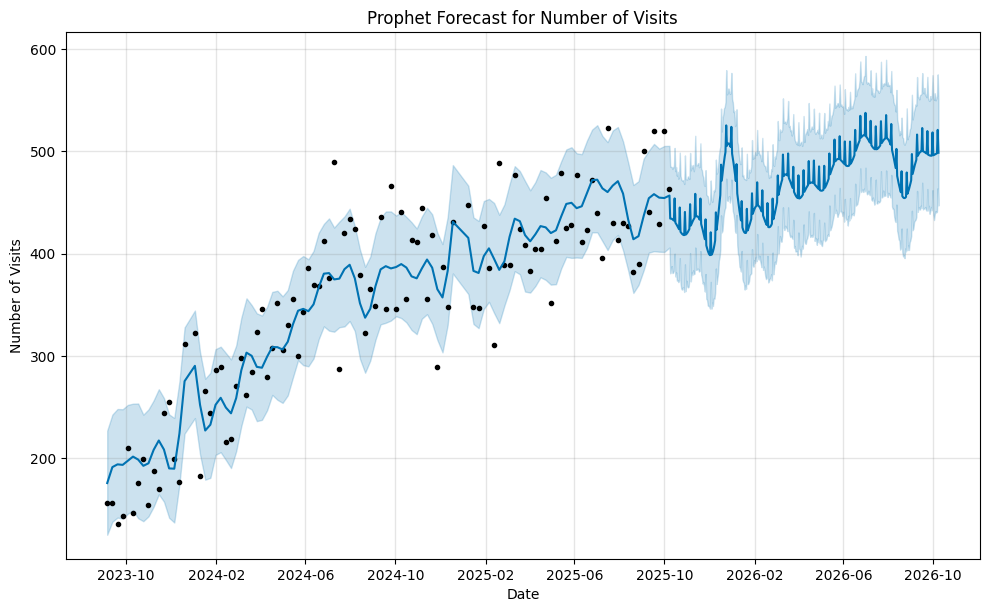

In [15]:
# Plot the forecast
fig1 = m.plot(forecast)
plt.title('Prophet Forecast for Number of Visits')
plt.xlabel('Date')
plt.ylabel('Number of Visits')
plt.show()

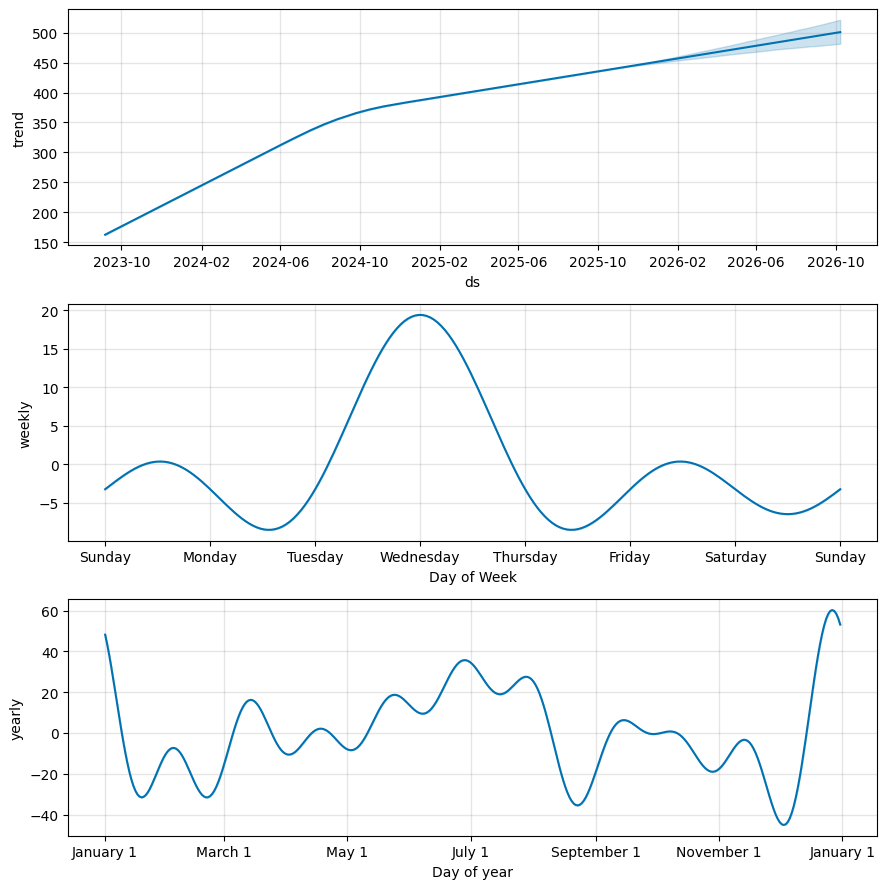

In [16]:
# Plot the individual components (overall trend, yearly seasonality, weekly seasonality)
fig2 = m.plot_components(forecast)